In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-vs-human/train.csv
/kaggle/input/ai-vs-human/test.csv


In [2]:

import re
import warnings
import itertools
import numpy as np 
import pandas as pd 
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import gensim
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix

2025-07-08 03:22:26.959863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751944947.159898      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751944947.218409      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
df = pd.read_csv("/kaggle/input/ai-vs-human/train.csv")

df

,id,text,generated
0,478725,Based on what I've read some believe Thai Thei...,0
1,452568,"Do you agree or disagree with ""imagination is ...",0
2,485245,"Pf you like to take trips around the world, th...",0
3,469782,Just before the bell rings to dismiss students...,0
4,475065,"Venus is sometimes called the"" Evening Star"". ...",0
...,...,...,...
31995,458076,The first time NASA first spotted to Faze on M...,0
31996,452064,There is an old proverb that states: “To thine...,1
31997,454865,A positive attitude is the key to success in l...,0
31998,482982,Some students take online classes they think i...,0


In [4]:
train_data = df['text']
train_label = df['generated']
type(train_data)

pandas.core.series.Series

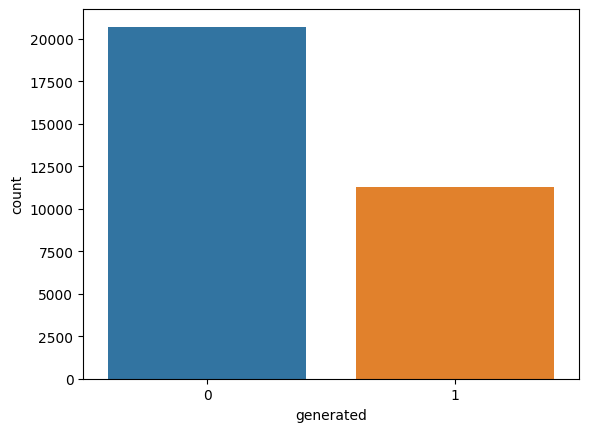

In [5]:
sns.countplot(x = train_label)
plt.show()

In [6]:
train_data

0        Based on what I've read some believe Thai Thei...
1        Do you agree or disagree with "imagination is ...
2        Pf you like to take trips around the world, th...
3        Just before the bell rings to dismiss students...
4        Venus is sometimes called the" Evening Star". ...
                               ...                        
31995    The first time NASA first spotted to Faze on M...
31996    There is an old proverb that states: “To thine...
31997    A positive attitude is the key to success in l...
31998    Some students take online classes they think i...
31999    Some schools require students to complete summ...
Name: text, Length: 32000, dtype: object

In [7]:
stop_words = set(stopwords.words('english'))
without_stop_words = []
for i in train_data:
    without_stop_words.append(re.sub(r'[^a-zA-Z0-9 ]', '', ' '.join([w.lower() for w in i.split() if not w.lower() in stop_words])))
without_stop_words[0]

'based read believe thai theirs face mars ii could linked io extraterrestrial life bui donti find io fruitful heres why look ai picture 1976 ii resemble face bui look ai 2001 picture ii looks like landform heres another thing one 1998 looks like volcanic activity emerging could case pictures contain important information data thai analyzed help nasa find oui this leis go back io viking 1 spacecraft machine built 1976 could possibly mean machines camera broken malfunctioning one major factor nasa nasa company studys life outside atmosphere launch probes space ii costs millions dollars io so find real life outside atmosphere gei paid research done theirs rumors thai certain people spread around usually iis unique bui theirs possibility thai iis true theorists io gain popularity themselves sometimes even money face mars gain lois popularity among time ii goi movies magazines even haunted grocery checkout lines bui among thai ii caused things'

In [8]:
cleaned_data = []

lemmatizer = WordNetLemmatizer()

for i in without_stop_words:
    cleaned_data.append(' '.join([lemmatizer.lemmatize(w) for w in i.split()]))
cleaned_data[0]


'based read believe thai theirs face mar ii could linked io extraterrestrial life bui donti find io fruitful here why look ai picture 1976 ii resemble face bui look ai 2001 picture ii look like landform here another thing one 1998 look like volcanic activity emerging could case picture contain important information data thai analyzed help nasa find oui this lei go back io viking 1 spacecraft machine built 1976 could possibly mean machine camera broken malfunctioning one major factor nasa nasa company study life outside atmosphere launch probe space ii cost million dollar io so find real life outside atmosphere gei paid research done theirs rumor thai certain people spread around usually ii unique bui theirs possibility thai ii true theorist io gain popularity themselves sometimes even money face mar gain lois popularity among time ii goi movie magazine even haunted grocery checkout line bui among thai ii caused thing'

In [9]:
tokens = []
for i in cleaned_data:
    tokens.append(word_tokenize(i))

In [10]:
model1 = gensim.models.Word2Vec(tokens, min_count=1,
                                vector_size=100, window=5)

In [11]:
# model1.wv.similarity('', '')

In [12]:
avg_vector = []
for query in tokens:
    avg_vector.append(model1.wv.get_mean_vector(query))
avg_vector[0]

array([-0.03341211,  0.03143725,  0.02352775, -0.04448647, -0.00361037,
        0.03170306, -0.00356475, -0.01420655, -0.01701156, -0.05131739,
        0.01670474,  0.01121642,  0.04613568,  0.03676075,  0.05445037,
       -0.02077961, -0.02601199, -0.0271553 , -0.01305424, -0.03863798,
       -0.00833044,  0.01875898,  0.01492316,  0.02526346, -0.03460669,
       -0.02395721, -0.08333618, -0.04191022,  0.01765474, -0.01905106,
       -0.00633291,  0.02925618,  0.00847645, -0.00658628,  0.02658334,
        0.01923298, -0.0425507 , -0.04929361, -0.02172066,  0.05761253,
        0.02123575,  0.0014288 , -0.04125113,  0.01018743, -0.00499563,
       -0.03748042,  0.00439282,  0.07172873,  0.01211391,  0.0190777 ,
        0.02936925,  0.00684177, -0.01787307, -0.01548015, -0.01273234,
        0.00882419, -0.01007857,  0.00667262, -0.00687806, -0.00429654,
        0.03422153,  0.05786083, -0.01582878, -0.0273012 ,  0.08986706,
       -0.02391218,  0.03307025,  0.01463439,  0.00062673,  0.04

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(avg_vector, train_label, test_size=0.20, random_state=42)

In [14]:
model = LogisticRegression(random_state=42)
model.fit(X_train, Y_train)

LogisticRegression(random_state=42)

In [15]:
Y_pred = model.predict(X_test)
print("F1_score" ,f1_score(Y_test, Y_pred))

cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:")
print(f"[[{cm[0,0]} {cm[0,1]}]")
print(f" [{cm[1,0]} {cm[1,1]}]]")

F1_score 0.9227982793751416
Confusion Matrix:
[[4021 102]
 [239 2038]]


In [16]:
dftest = pd.read_csv("/kaggle/input/ai-vs-human/test.csv")
dftest

,id,text
0,458456,"Dear principle,\n\nThe cell fine use policy's ..."
1,475311,"The article ""Driverless Cars are Coming"" disc..."
2,451806,A chain that evaluates the author idea is... N...
3,483704,I think that others should participate in the ...
4,472679,Studying Venus Remains a Worth Scientific Purs...
...,...,...
7995,451330,"In Vauban, Germany, there are no cars. The onl..."
7996,473506,The Electoral College has been around since th...
7997,449792,"The electoral college JS pointless, I believe ..."
7998,461953,"In thy article ""Driverless Cars ARY Coming"", t..."


In [17]:
output_id = dftest['id']
output_text = dftest['text']

In [18]:
without_stop_words_test = []
for i in output_text:
    without_stop_words_test.append((re.sub(r'[^a-zA-Z0-9 ]', '', ' '.join([w.lower() for w in i.split() if not w.lower() in stop_words]))))


In [19]:
cleaned_data_test = []
for i in without_stop_words_test:
    cleaned_data_test.append(' '.join([lemmatizer.lemmatize(w) for w in i.split()]))
cleaned_data_test[0]


'dear principle cell fine use policy come tj attention student use phone almost every period cell fine rule place right new working kid get away texting class distracting tj work lower grade policy place right new student bring fine tj school tj turned off kid use phone anyway tell tj use phone going tj use anyway tell could use phone lunch free time use much class student grade dropping cell fine use class policy number two best policy student show trust let need tj call parent time tj dj instead going tj bathroom tj call them trust me student sincerely favorite student studentname'

In [20]:
tokens_test = []
for i in cleaned_data_test:
    tokens_test.append(word_tokenize(i))

In [21]:
avg_vector_test = []
for query in tokens_test:
    avg_vector_test.append(model1.wv.get_mean_vector(query))
avg_vector_test[0]

array([-0.01241364, -0.01696891, -0.02461019, -0.01717511, -0.00224753,
        0.03522907,  0.01381185, -0.08899435,  0.01308897,  0.07390546,
        0.05152999,  0.04469005, -0.07221274, -0.01628635,  0.05146725,
       -0.03875198,  0.06905846, -0.02763017, -0.00974501,  0.01139508,
       -0.04217578,  0.01094458, -0.04240051,  0.02810038,  0.01465522,
       -0.03502758,  0.00890883, -0.02180778,  0.01412384,  0.01912076,
       -0.07630731,  0.04149921, -0.00683381, -0.0266326 ,  0.03600759,
        0.02924973,  0.04297112, -0.02779025,  0.02020349,  0.06268863,
       -0.03074923, -0.10349009,  0.00356289, -0.01978557, -0.03424656,
       -0.01390358, -0.08035354, -0.02072135,  0.01255935,  0.06220224,
       -0.02936335,  0.06825522, -0.0156342 , -0.01436804,  0.01134166,
       -0.03338732,  0.02146058, -0.07122289,  0.00197239,  0.01425015,
        0.06371997, -0.0091817 ,  0.03661858, -0.02592654,  0.06111469,
       -0.08223737, -0.0488492 ,  0.01105368,  0.02007198, -0.03

In [22]:
type(avg_vector_test[0])

numpy.ndarray

In [23]:
# final['id'] = np.array(output_id)
dftest['generated'] = model.predict(avg_vector_test)

In [24]:
dftest['generated'].value_counts()

generated
0    5387
1    2613
Name: count, dtype: int64

In [25]:
dftest[['id','generated']].to_csv("output3.csv", index=False)

In [26]:
demo_sentence = ["Arnold is CEO head coach"]


without_stop_words_test = []
for i in demo_sentence:
    without_stop_words_test.append((re.sub(r'[^a-zA-Z0-9 ]', '', ' '.join([w.lower() for w in i.split() if not w.lower() in stop_words]))))

cleaned_data_test = []
for i in without_stop_words_test:
    cleaned_data_test.append(' '.join([lemmatizer.lemmatize(w) for w in i.split()]))
cleaned_data_test[0]

tokens_test = []
for i in cleaned_data_test:
    tokens_test.append(word_tokenize(i))

avg_vector_test = []
for query in tokens_test:
    avg_vector_test.append(model1.wv.get_mean_vector(query))

demo_predict = model.predict(avg_vector_test)
if(demo_predict == 1):
    print("AI Generated!")
else:
    print("Human Written")


Human Written


In [27]:
pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.3/54.3 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.9/323.9 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.6/95.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 95.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [28]:
import gradio as gr
import re
from nltk.tokenize import word_tokenize

# Example: stop_words and lemmatizer must be defined somewhere in your code
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# stop_words = set(stopwords.words('english'))
# lemmatizer = WordNetLemmatizer()

# Your prediction function
def predict_text(input_text):
    # 1. Remove stopwords & punctuation
    without_stop_words_test = []
    without_stop_words_test.append((
        re.sub(
            r'[^a-zA-Z0-9 ]',
            '',
            ' '.join([w.lower() for w in input_text.split() if not w.lower() in stop_words])
        )
    ))

    # 2. Lemmatize
    cleaned_data_test = []
    for i in without_stop_words_test:
        cleaned_data_test.append(' '.join([lemmatizer.lemmatize(w) for w in i.split()]))

    # 3. Tokenize
    tokens_test = []
    for i in cleaned_data_test:
        tokens_test.append(word_tokenize(i))

    # 4. Average embedding vector
    avg_vector_test = []
    for query in tokens_test:
        avg_vector_test.append(model1.wv.get_mean_vector(query))

    # 5. Predict
    demo_predict = model.predict(avg_vector_test)
    if demo_predict == 1:
        return "AI Generated!"
    else:
        return "Human Written"

# Create Gradio interface
iface = gr.Interface(
    fn=predict_text,
    inputs=gr.Textbox(lines=3, placeholder="Enter your sentence here..."),
    outputs="text",
    title="AI vs Human Text Classifier",
    description="Enter a sentence to predict if it was written by AI or a human."
)

if __name__ == "__main__":
    iface.launch()


* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://bf6b3832bd3a826a27.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
